# SAR - Ground Surface Deformation Workflow

Simple end-to-end workflow for SAR-based ground deformation detection.

This script demonstrates the complete SAR GRD workflow from data download to visualization.
Uses intensity-based change detection (not interferometric phase).

### 1 - Import libraries, setup configurations, initialize a logger

In [1]:
# TEMPORARY CONFIGURATION TO RUN THE NOTEBOOK LOCALLY
SRC_DIR = r"D:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\src"
import os
os.chdir(SRC_DIR)
os.getcwd()

DOWNLOAD_FILES = False


In [2]:
import logging
from pathlib import Path
import sys
import numpy as np

# Add src to path
sys.path.insert(0, SRC_DIR)

from sar_gsd.config import Config
from sar_gsd.download import CDSEDownloader
from sar_gsd.cubes import create_datacube_from_files, save_datacube, load_datacube
from sar_gsd.timeseries import detect_linear_trends
from sar_gsd.deformation import (
    classify_deformation_zones, 
    identify_deformation_hotspots,
    landslide_susceptibility
)
from sar_gsd.visualization import (
    plot_velocity_map, 
    plot_deformation_classification,
    plot_hotspots,
    plot_susceptibility_map,
    plot_deformation_histogram,
    plot_timeseries
)

<font color='lightgreen'>Config.validate_credentials()</font> checks if the credentials on the .env file are configured.

In [3]:
Config.validate_credentials()

True

Setup a logger and retrieve configuration attributes (bounding box, start and end date) for provided tartget areas.

In [4]:
# Run complete SAR-based ground deformation detection workflow

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)-8s - [%(filename)s:%(lineno)d] %(message)s'
)
logger = logging.getLogger("sar_gsd")

logger.info("SAR Ground Deformation Detection - Example Workflow")
logger.info("=" * 60)

# Configuration
study_area = Config.get_study_area_config("test_area")

bbox = study_area['bbox']
start_date = study_area['start_date']
end_date = study_area['end_date']

logger.info(f"Study Area: {study_area['name']}")
logger.info(f"Bounding Box: {bbox}")
logger.info(f"Date Range: {start_date} to {end_date}")

INFO:sar_gsd:SAR Ground Deformation Detection - Example Workflow
INFO:sar_gsd:============================================================
INFO:sar_gsd:Study Area: Test Area: Ipatinga, Minas Gerais, Brazil
INFO:sar_gsd:Bounding Box: [-42.843182, -19.645174, -42.488873, -19.396658]
INFO:sar_gsd:Date Range: 2020-01-01 to 2025-12-31


### 2 - Query and download SAR products from Copernicus Open Access Hub

Instantiate a CDSEDownload class, get access token, queries a request to the API, and perform download of Sentinel-1 GRD data.

<font color='lightgreen'>downloader.download_products()</font> will retrieve large size files, so keep in mind that download times may be long.

**NEW FEATURE: Bounding Box Clipping**
- Set `CLIP_TO_BBOX = True` to automatically clip downloaded products to your study area
- This significantly reduces file sizes (typically 70-90% reduction)
- Clipped products are saved as GeoTIFF files instead of full .SAFE.zip archives

Optionally queries Copernicus for available GRD products in a given area and date range, then selects up to five products closest to equally spaced dates between the start and end dates.
Those selected products are downloaded. If downloading is disabled (DOWNLOAD_FILES = False) or fails, it falls back to using already existing local data files.

Optionally, data already downloaded and available for the following steps of the workflow is available at https://drive.google.com/drive/folders/1cgr3I5Cvl5lywm_yk5TDyQ9F_P-stKZ5?usp=sharing.

In [5]:
max_products = 5
CLIP_TO_BBOX = True  # Set to True to automatically clip products to bounding box

logger.info("\n" + "=" * 60)
logger.info("Step 1: Data Download")
logger.info("=" * 60)

if DOWNLOAD_FILES:
    try:
        if not Config.validate_credentials():
            logger.warning("Copernicus credentials not configured. Skipping download.")
            logger.info("Please set credentials in .env file to enable data download")
            downloaded_files = []
        else:
            downloader = CDSEDownloader()
            
            # Query available products
            products_df = downloader.query_products(
                bbox=bbox,
                start_date=start_date,
                end_date=end_date,
                product_type="GRD"
            )

            logger.info(f"Found {len(products_df)} available products")

            # Download 1 product from each of 5 equally spaced dates
            if len(products_df) > 0:
                from datetime import datetime, timedelta
                import pandas as pd
                
                # Parse start and end dates
                start_dt = datetime.strptime(start_date, "%Y-%m-%d")
                end_dt = datetime.strptime(end_date, "%Y-%m-%d")
                
                # Create equally spaced target dates
                total_days = (end_dt - start_dt).days
                target_dates = [start_dt + timedelta(days=total_days * i / 4) for i in range(max_products)]
                
                # Convert product dates to datetime for comparison
                products_df['datetime'] = pd.to_datetime(products_df['start_date']).dt.tz_localize(None)
                
                # Select one product closest to each target date
                selected_products = []
                for target_date in target_dates:
                    # Find products closest to this target date
                    products_df['time_diff'] = abs(products_df['datetime'] - target_date)
                    closest_product = products_df.loc[products_df['time_diff'].idxmin()]
                    
                    # Avoid duplicates
                    if closest_product.name not in [p.name for p in selected_products]:
                        selected_products.append(closest_product)
                
                # Create dataframe with selected products
                selected_df = pd.DataFrame(selected_products)
                
                logger.info(f"Selected {len(selected_df)} products from equally spaced dates")
                
                # Download with optional bbox clipping
                downloaded_files = downloader.download_products(
                    selected_df,
                    max_products=len(selected_df),
                    clip_to_bbox=CLIP_TO_BBOX,
                    bbox=bbox if CLIP_TO_BBOX else None,
                    polarization='vv'
                )
            else:
                downloaded_files = []
    except Exception as e:
        logger.error(f"Download failed: {e}")
        logger.info("Continuing with existing data if available...")
        downloaded_files = []
        
else:
    logger.info("Data already downloaded.")
    # Look for both .zip and .tif files
    downloaded_files = list(Config.RAW_DATA_DIR.glob("*.zip")) + list(Config.RAW_DATA_DIR.glob("*_clipped_*.tif"))
    downloaded_files = [f for f in downloaded_files if f.is_file()]
        
    logger.info(f"Data paths ({len(downloaded_files)} files): {downloaded_files}")

INFO:sar_gsd:
INFO:sar_gsd:Step 1: Data Download
INFO:sar_gsd:============================================================
INFO:sar_gsd:Data already downloaded.
INFO:sar_gsd:Data paths (3 files): [WindowsPath('D:/Flávio Rocha USER/OneDrive/GIT/SAR_GSD/data/raw/S1A_IW_GRDH_1SDV_20240625T082207_20240625T082232_054477_06A11E_1B24.SAFE.zip'), WindowsPath('D:/Flávio Rocha USER/OneDrive/GIT/SAR_GSD/data/raw/S1B_IW_GRDH_1SDV_20200112T082051_20200112T082116_019781_025668_CCBF.SAFE.zip'), WindowsPath('D:/Flávio Rocha USER/OneDrive/GIT/SAR_GSD/data/raw/S1B_IW_GRDH_1SDV_20210705T082101_20210705T082126_027656_034CFB_BA7E.SAFE.zip')]


### 3 - Creating Data Cubes from SAR Data

In [6]:
logger.info("\n" + "=" * 60)
logger.info("Step 2: Create Data Cube")
logger.info("=" * 60)

if downloaded_files and len(downloaded_files) >= 3:
    # Create from downloaded files
    logger.info(f"Creating datacube from {len(downloaded_files)} files")
    
    try:
        # Use unzip=True to automatically extract and read from .SAFE.zip files
        datacube = create_datacube_from_files(
            file_paths=downloaded_files,
            band_name="intensity",
            unzip=True,  # Enable automatic unzipping of .SAFE.zip files
            polarization='vv',  # Choose polarization: 'vv' or 'vh'
            cleanup=True  # Automatically clean up extracted files after processing
        )        
    except Exception as e:
        logger.error(f"Failed to create datacube: {e}")
else:
    logger.info("Insufficient data files.")

INFO:sar_gsd:
INFO:sar_gsd:Step 2: Create Data Cube
INFO:sar_gsd:============================================================
INFO:sar_gsd:Creating datacube from 3 files
INFO:sar_gsd.cubes:Creating datacube from 3 files
INFO:sar_gsd.cubes:Processing zip file: S1A_IW_GRDH_1SDV_20240625T082207_20240625T082232_054477_06A11E_1B24.SAFE.zip
INFO:sar_gsd.cubes:Extracting S1A_IW_GRDH_1SDV_20240625T082207_20240625T082232_054477_06A11E_1B24.SAFE.zip to C:\Users\fhroc\AppData\Local\Temp\tmp31bmu2m2
INFO:sar_gsd.cubes:Processing zip file: S1B_IW_GRDH_1SDV_20200112T082051_20200112T082116_019781_025668_CCBF.SAFE.zip
INFO:sar_gsd.cubes:Extracting S1B_IW_GRDH_1SDV_20200112T082051_20200112T082116_019781_025668_CCBF.SAFE.zip to C:\Users\fhroc\AppData\Local\Temp\tmp120b1h_o
INFO:sar_gsd.cubes:Processing zip file: S1B_IW_GRDH_1SDV_20210705T082101_20210705T082126_027656_034CFB_BA7E.SAFE.zip
INFO:sar_gsd.cubes:Extracting S1B_IW_GRDH_1SDV_20210705T082101_20210705T082126_027656_034CFB_BA7E.SAFE.zip to C:\User

In [7]:
# Save datacube
datacube_path = Config.PROCESSED_DATA_DIR / "example_datacube.nc"
datacube_path = Path(os.environ.get('LOCALAPPDATA', 'C:/temp')) / 'SAR_GSD' / datacube_path.name
logger.info(f'Saving data cube to {datacube_path}')
save_datacube(datacube, datacube_path)
logger.info(f"Datacube saved to {datacube_path}")
logger.info(f"Datacube shape: {datacube.shape}")
logger.info(f"Time steps: {len(datacube.time)}")

INFO:sar_gsd:Saving data cube to C:\Users\fhroc\AppData\Local\SAR_GSD\example_datacube.nc
INFO:sar_gsd.cubes:Saved datacube to C:\Users\fhroc\AppData\Local\SAR_GSD\example_datacube.nc
INFO:sar_gsd.cubes:File size: 487.58 MB
INFO:sar_gsd:Datacube saved to C:\Users\fhroc\AppData\Local\SAR_GSD\example_datacube.nc
INFO:sar_gsd:Datacube shape: (3, 16841, 26070)
INFO:sar_gsd:Time steps: 3


In [8]:
# Load datacube (testing load function)
datacube_path = Config.PROCESSED_DATA_DIR / "example_datacube.nc"
datacube_path = Path(os.environ.get('LOCALAPPDATA', 'C:/temp')) / 'SAR_GSD' / datacube_path.name

datacube = load_datacube(datacube_path)
datacube

INFO:sar_gsd.cubes:Loaded datacube from C:\Users\fhroc\AppData\Local\SAR_GSD\example_datacube.nc
INFO:sar_gsd.cubes:Dataset sizes: Frozen({np.str_('time'): 3, 'y': 16841, 'x': 26070})


<xarray.DataArray 'intensity' (time: 3, y: 16841, x: 26070)> Size: 5GB
[1317134610 values with dtype=float32]
Coordinates:
  * time         (time) object 24B 2024-06-25 00:00:00 ... 2021-07-05 00:00:00
  * y            (y) float64 135kB 1.684e+04 1.684e+04 1.684e+04 ... 2.0 1.0 0.0
  * x            (x) float64 209kB 0.0 1.0 2.0 ... 2.607e+04 2.607e+04 2.607e+04
    spatial_ref  int64 8B 0
Attributes: (12/16)
    NETCDF_DIM_EXTRA:          {time}
    NETCDF_DIM_time_DEF:       [ 3. 10.]
    NETCDF_DIM_time_VALUES:    [    0. -1626. -1086.]
    TIFFTAG_IMAGEDESCRIPTION:  Sentinel-1A IW GRD HR L1
    TIFFTAG_SOFTWARE:          Sentinel-1 IPF 003.80
    TIFFTAG_DATETIME:          2024:06:25 10:26:48
    ...                        ...
    n_scenes:                  3
    start_date:                2024-06-25 00:00:00
    end_date:                  2021-07-05 00:00:00
    polarization:              vv
    coordinates:               band
    _FillValue:                nan

MemoryError: Unable to allocate 6.54 GiB for an array with shape (16842, 26071, 2) and data type float64

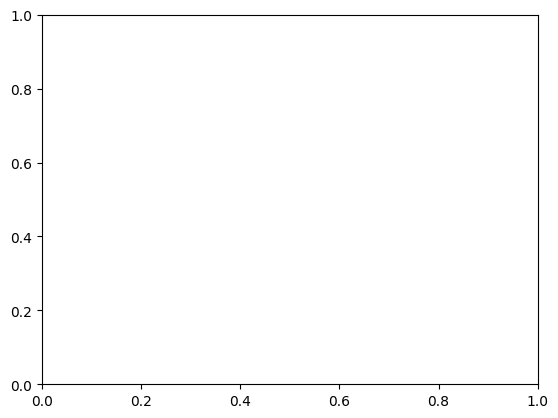

In [12]:
datacube.isel(time=0).plot()

### 4 - Time Series Analysis: Detect Linear Deformation Trends

This step analyzes the time series datacube to detect linear deformation trends using robust regression (RANSAC).

Outputs:
- **velocity**: Linear deformation velocity in mm/year (negative = subsidence, positive = uplift)
- **pvalue**: Statistical significance of the trend
- **rsquared**: Goodness of fit (0-1)

In [ ]:
logger.info("\n" + "=" * 60)
logger.info("Step 3: Time Series Analysis")
logger.info("=" * 60)

# Detect linear deformation trends
logger.info("Detecting linear deformation trends...")
velocity, pvalue, rsquared = detect_linear_trends(datacube, robust=True)

# Log statistics
logger.info(f"\nVelocity Statistics:")
logger.info(f"  Mean velocity: {velocity.mean().values:.2f} mm/year")
logger.info(f"  Median velocity: {float(velocity.median().values):.2f} mm/year")
logger.info(f"  Std deviation: {velocity.std().values:.2f} mm/year")
logger.info(f"  Range: [{velocity.min().values:.2f}, {velocity.max().values:.2f}] mm/year")

logger.info(f"\nRegression Quality:")
logger.info(f"  Mean R²: {rsquared.mean().values:.3f}")
logger.info(f"  % pixels with p-value < 0.05: {(pvalue < 0.05).sum().values / pvalue.size * 100:.1f}%")

### 5 - Deformation Analysis

Apply deformation-specific algorithms:
1. **Classification**: Categorize pixels into deformation classes (stable, slow/moderate/fast subsidence, uplift)
2. **Hotspot Detection**: Identify contiguous areas of significant deformation
3. **Susceptibility**: Calculate landslide susceptibility based on deformation velocity

In [ ]:
logger.info("\n" + "=" * 60)
logger.info("Step 4: Deformation Analysis")
logger.info("=" * 60)

# 1. Classify deformation zones
logger.info("\n1. Classifying deformation zones...")
deformation_classes = classify_deformation_zones(velocity)

# Count pixels in each class
class_counts = {}
for class_id, class_name in deformation_classes.attrs['classes'].items():
    count = (deformation_classes == class_id).sum().values
    class_counts[class_name] = count
    logger.info(f"  {class_name}: {count:,} pixels ({count/deformation_classes.size*100:.1f}%)")

# 2. Identify deformation hotspots
logger.info("\n2. Identifying deformation hotspots...")
hotspots, hotspot_stats = identify_deformation_hotspots(
    velocity,
    threshold=15.0,  # mm/year
    min_size=10      # minimum pixels
)

logger.info(f"  Found {len(hotspot_stats)} deformation hotspots")

if len(hotspot_stats) > 0:
    logger.info(f"\n  Top 5 hotspots by size:")
    for idx, row in hotspot_stats.nlargest(5, 'size_pixels').iterrows():
        logger.info(f"    Hotspot {row['hotspot_id']}: "
                    f"{row['size_pixels']} pixels, "
                    f"mean velocity: {row['mean_velocity_mm_year']:.2f} mm/year, "
                    f"max velocity: {row['max_velocity_mm_year']:.2f} mm/year")

# 3. Calculate landslide susceptibility
logger.info("\n3. Calculating landslide susceptibility...")
susceptibility = landslide_susceptibility(velocity)

logger.info(f"  Mean susceptibility: {susceptibility.mean().values:.3f}")
logger.info(f"  High risk pixels (>0.7): {(susceptibility > 0.7).sum().values:,} "
            f"({(susceptibility > 0.7).sum().values/susceptibility.size*100:.1f}%)")

### 6 - Visualization

### 6 - Visualization

Create comprehensive visualizations of deformation analysis results:
1. Velocity map
2. Deformation classification map
3. Hotspots overlay
4. Landslide susceptibility map
5. Velocity histogram
6. Time series plot for a sample pixel

In [ ]:
logger.info("\n" + "=" * 60)
logger.info("Step 5: Visualization")
logger.info("=" * 60)

output_dir = Config.OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Plot velocity map
logger.info("\n1. Creating velocity map...")
plot_velocity_map(
    velocity,
    save_path=output_dir / "01_velocity_map.png",
    title="Deformation Velocity Map (mm/year)"
)

# 2. Plot deformation classification
logger.info("2. Creating deformation classification map...")
plot_deformation_classification(
    deformation_classes,
    save_path=output_dir / "02_deformation_classification.png",
    title="Deformation Classification"
)

# 3. Plot hotspots
logger.info("3. Creating hotspots map...")
plot_hotspots(
    hotspots,
    velocity_map=velocity,
    save_path=output_dir / "03_deformation_hotspots.png",
    title="Deformation Hotspots"
)

# 4. Plot susceptibility map
logger.info("4. Creating landslide susceptibility map...")
plot_susceptibility_map(
    susceptibility,
    save_path=output_dir / "04_landslide_susceptibility.png",
    title="Landslide Susceptibility"
)

# 5. Plot velocity histogram
logger.info("5. Creating velocity histogram...")
plot_deformation_histogram(
    velocity,
    save_path=output_dir / "05_velocity_histogram.png",
    bins=100
)

logger.info(f"\nAll visualizations saved to: {output_dir}")

In [ ]:
# 6. Plot sample time series
logger.info("6. Creating time series plot for sample pixel...")

# Find a pixel with significant deformation (high velocity)
velocity_abs = abs(velocity.values)
max_def_idx = np.unravel_index(np.nanargmax(velocity_abs), velocity_abs.shape)
max_def_y, max_def_x = max_def_idx

logger.info(f"  Selected pixel at ({max_def_y}, {max_def_x}) with velocity = {velocity.values[max_def_y, max_def_x]:.2f} mm/year")

plot_timeseries(
    datacube,
    pixel_coords=(max_def_y, max_def_x),
    save_path=output_dir / "06_timeseries_max_deformation.png",
    title=f"Time Series at Max Deformation Pixel ({max_def_y}, {max_def_x})\nVelocity: {velocity.values[max_def_y, max_def_x]:.2f} mm/year"
)

logger.info("\nVisualization complete!")

In [ ]:
# Summary
logger.info("\n" + "=" * 60)
logger.info("Workflow Complete!")
logger.info("=" * 60)
logger.info(f"Processed {len(datacube.time)} time steps")
logger.info(f"Detected {len(hotspot_stats)} deformation hotspots")
logger.info(f"Mean coherence: {coherence.mean().values:.3f}")
logger.info(f"Outputs saved to: {output_dir}")

### 7 - Summary and Results

Display summary statistics and key findings from the deformation analysis.

In [ ]:
# Display hotspot statistics table (if any hotspots found)
if len(hotspot_stats) > 0:
    print("\n" + "=" * 80)
    print("DEFORMATION HOTSPOTS - DETAILED STATISTICS")
    print("=" * 80)
    print(hotspot_stats.to_string(index=False))
    print("=" * 80)
else:
    print("\nNo deformation hotspots detected with current threshold.")

In [ ]:
logger.info("\n" + "=" * 60)
logger.info("WORKFLOW COMPLETE - SUMMARY")
logger.info("=" * 60)

logger.info(f"\n📊 DATA PROCESSING:")
logger.info(f"  • Processed {len(datacube.time)} SAR scenes")
logger.info(f"  • Time range: {str(datacube.time.values[0])[:10]} to {str(datacube.time.values[-1])[:10]}")
logger.info(f"  • Datacube shape: {datacube.shape} (time, y, x)")
logger.info(f"  • Spatial extent: {datacube.shape[1]} × {datacube.shape[2]} pixels")

logger.info(f"\n📈 DEFORMATION TRENDS:")
logger.info(f"  • Mean velocity: {velocity.mean().values:.2f} mm/year")
logger.info(f"  • Velocity range: [{velocity.min().values:.2f}, {velocity.max().values:.2f}] mm/year")
logger.info(f"  • Mean R²: {rsquared.mean().values:.3f}")

logger.info(f"\n🎯 DEFORMATION CLASSIFICATION:")
for class_id, class_name in deformation_classes.attrs['classes'].items():
    count = (deformation_classes == class_id).sum().values
    pct = count/deformation_classes.size*100
    logger.info(f"  • {class_name}: {count:,} pixels ({pct:.1f}%)")

logger.info(f"\n🔥 HOTSPOT DETECTION:")
logger.info(f"  • Identified {len(hotspot_stats)} deformation hotspots")
if len(hotspot_stats) > 0:
    total_hotspot_pixels = hotspot_stats['size_pixels'].sum()
    logger.info(f"  • Total hotspot area: {total_hotspot_pixels:,} pixels")
    logger.info(f"  • Largest hotspot: {hotspot_stats['size_pixels'].max()} pixels")

logger.info(f"\n⚠️ LANDSLIDE SUSCEPTIBILITY:")
logger.info(f"  • Mean susceptibility: {susceptibility.mean().values:.3f}")
high_risk = (susceptibility > 0.7).sum().values
logger.info(f"  • High risk pixels (>0.7): {high_risk:,} ({high_risk/susceptibility.size*100:.1f}%)")

logger.info(f"\n📁 OUTPUTS:")
logger.info(f"  • Datacube: {datacube_path}")
logger.info(f"  • Visualizations: {output_dir}")
logger.info(f"  • {len(list(output_dir.glob('*.png')))} plots generated")

logger.info("\n" + "=" * 60)
logger.info("✅ Analysis complete! Check the output directory for results.")
logger.info("=" * 60)